In [45]:
import sys
sys.path.append("../")
import importlib

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

import GNNInterpreter
from GNNInterpreter.gnninterpreter import *


In [131]:
config = {
    "DATASET_NAME": "PROTEINS", 
    "MAX_NODES": 20, 
    "device": "cpu"
}

# Data

In [132]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [133]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=100,
    batch_size=32,
    lr=1e-3,
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/100] train_loss=0.6189  val_acc=0.640
[002/100] train_loss=0.5893  val_acc=0.712
[003/100] train_loss=0.5628  val_acc=0.703
[004/100] train_loss=0.5668  val_acc=0.730
[005/100] train_loss=0.5397  val_acc=0.757
[006/100] train_loss=0.5432  val_acc=0.721
[007/100] train_loss=0.5666  val_acc=0.748
[008/100] train_loss=0.5321  val_acc=0.739
[009/100] train_loss=0.5247  val_acc=0.739
[010/100] train_loss=0.5232  val_acc=0.712
[011/100] train_loss=0.5174  val_acc=0.748
[012/100] train_loss=0.5269  val_acc=0.757
[013/100] train_loss=0.5201  val_acc=0.757
[014/100] train_loss=0.5271  val_acc=0.730
[015/100] train_loss=0.5245  val_acc=0.757
[016/100] train_loss=0.5175  val_acc=0.739
[017/100] train_loss=0.5296  val_acc=0.712
[018/100] train_loss=0.5180  val_acc=0.757
[019/100] train_loss=0.5272  val_acc=0.739
[020/100] train_loss=0.5143  val_acc=0.739
[021/100] train_loss=0.5090  val_acc=0.766
[022/100] train_loss=0.5151  val_acc=0.739
[023/100] train_loss=0.5105  val_acc=0.757
[024/100] t

# Generator

In [134]:
def train_generator(cls_idx, data):
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=config.get("MAX_NODES"),
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.EDGE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", criterion=ClassScoreCriterion(class_idx=cls_idx, mode='maximize'), weight=1),
            dict(key="embeds", criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_idx]), weight=50),
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=10, order=2, beta=1),
    )

    trainer.train(
        iterations=200,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

  0%|          | 0/200 [00:00<?, ?it/s]

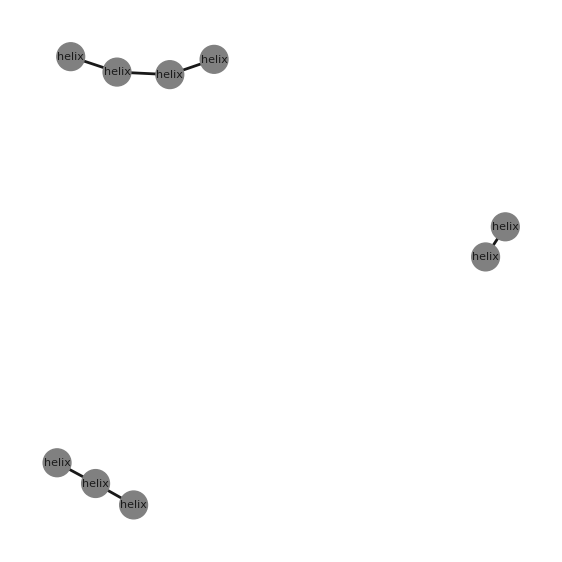

In [136]:
import new_src.utils
from new_src.utils import plot_graph
importlib.reload(new_src.utils)



sample = train_generator(0, data), 
plot_graph(sample[0], data)

# Evaluation